**Load Packages**

In [29]:
import pandas as pd
import numpy as np
import torch
import pymanopt
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ortho_group
from tqdm import tqdm 
from joblib import Parallel, delayed
import os
if not os.path.exists('figs'): os.makedirs('figs')
if not os.path.exists('data'): os.makedirs('data')

**Data Preprocessing**

In [30]:
df = pd.read_stata('data/Institutions/Institutions.DTA')
needed = ["gdp_pc_ca9500", "pc_institutions", "literacy1880", "edu_aggregate",  "pc_all4_tol", "pc_all3","tolerance","trust", "obedience","control", "urb_1860_1850_30"  ]
df = df[needed]
df = df.dropna()

np.random.seed(1)                               #randomness in pilot data split
xcols = ["pc_institutions","literacy1880", "edu_aggregate",  "pc_all4_tol", "urb_1860_1850_30" ]
df_X = df[xcols]
df_y = np.log(df[ "gdp_pc_ca9500"])


#Source: Urbanization < 2
id_s = df['urb_1860_1850_30'] <2
x_s = df_X[id_s]
y_s = df_y[id_s]

#Target: Urbanization >= 10
id_t = df['urb_1860_1850_30'] >=10
tempX = df_X[id_t]
tempY = df_y[id_t]


#Pilot Data Split
x_t = tempX.sample(frac = 0.80).sort_index()
y_t = tempY.loc[tempY.index.isin(x_t.index)].sort_index()
x_pilot = tempX.loc[~tempX.index.isin(x_t.index)].sort_index()
y_pilot = tempY.loc[~tempY.index.isin(x_t.index)].sort_index()


#Standardization
xmean = pd.concat([x_s]).mean()
xstd = pd.concat([x_s]).std()

#Don't standardize environment variable
xstd['urb_1860_1850_30'] = 1
xmean['urb_1860_1850_30'] = 0

x_s = (x_s - xmean)/xstd
x_t = (x_t - xmean)/xstd
x_pilot = (x_pilot - xmean)/xstd


n = len(y_s)
m = len(y_t)
d = x_s.shape[1]-1

**Regression**

We run the usual OLS regression using the source data, check its risk on the target data, and compare to the risk of the target OLS regression.

In [31]:
# source risk
def R_s(beta):
    return np.sqrt(np.mean((y_s - x_s @ beta)**2))

# target risk
def R_t(beta):
    return np.sqrt(np.mean((y_t - x_t @ beta)**2))

#pilot (test) data load... 
def R_pilot(beta):
    return np.sqrt(np.mean((y_pilot - x_pilot @ beta)**2))

x_s = x_s.to_numpy().astype(np.float64)
y_s = y_s.to_numpy().astype(np.float64)
x_t = x_t.to_numpy().astype(np.float64)
y_t = y_t.to_numpy().astype(np.float64)
x_pilot = x_pilot.to_numpy().astype(np.float64)
y_pilot = y_pilot.to_numpy().astype(np.float64)

# source OLS
model_s = sm.OLS(y_s, x_s)
res_s = model_s.fit()
beta_s = res_s.params

# target OLS (oracle)
model_t = sm.OLS(y_t, x_t)
res_t = model_t.fit()
beta_t = res_t.params

# pilot OLS (oracle)
model_p = sm.OLS(y_pilot, x_pilot)
res_p = model_p.fit()
beta_p = res_p.params

print('Source OLS risk =', R_s(beta_s))
print('Target OLS risk (oracle) =', R_t(beta_t))
print('Target risk of source OLS =', R_t(beta_s))

Source OLS risk = 3.8120540446980438
Target OLS risk (oracle) = 1.6750736819064036
Target risk of source OLS = 89.8164673129766


**Proposed Method**

In [32]:
np.random.seed(12)
d = x_s.shape[1]
x_s_ = torch.from_numpy(x_s)
y_s_ = torch.from_numpy(y_s)
XX_s_ = x_s_.T @ x_s_ / n
x_t_ = torch.from_numpy(np.vstack((x_pilot, x_t))) 
XX_t_ = x_t_.T @ x_t_ / m


#Number of parallel runs: Default = 1
batch_size = 1

# Grid search over parameters
dim_range = np.arange(1, d+1)
eta_range = np.array([1e-12, 1e-10,1e-8,  1e-6, 1e-4,1e-2,  1, 1e+2])#np.array([1e-4, 1e-3,1e-2,  1e-1,1, 1e+1,1e+2,  1e+3,1e+4, 1e+5, 1e+6, 1e+7, 1e+8, 1e+9, 1e+10, 1e+11, 1e+12])
ups_range = np.array([0, 0.1, 1])

# Storage
V_list = np.zeros((len(dim_range), len(ups_range), len(eta_range), batch_size, d, d ))
betas_ridge = np.zeros((len(dim_range), len(ups_range), len(eta_range),batch_size, d))
target_risks_ridge = np.zeros((len(dim_range), len(ups_range), len(eta_range), batch_size))
source_risks_ridge = np.zeros((len(dim_range), len(ups_range), len(eta_range), batch_size))
pilot_risks_ridge = np.zeros((len(dim_range), len(ups_range), len(eta_range), batch_size))

#Generate random initializations if batch_size > 1
init_list = []
init_list.append(np.diag(np.ones(d)))
for b in range(batch_size-1):
    init_list.append(ortho_group.rvs(dim = d))


def optimroutine(init_point, problem, optimizer):
    result = optimizer.run(problem, initial_point= init_point) # intialized with identity
    V = result.point

    #check performance
    alpha_ridge = np.linalg.pinv(V.T @ (x_s.T @ x_s / n) @ V + ups*np.eye(k)) @ V.T @ x_s.T @ y_s / n
    beta_ridge = V @ alpha_ridge

    return V@V.T,  beta_ridge.T, R_pilot(beta_ridge), R_s(beta_ridge), R_t(beta_ridge)

#Optimize over hyperparameter grid
for h, k in enumerate(dim_range):
    manifold = pymanopt.manifolds.stiefel.Stiefel(d, k)
    for j, ups in tqdm(enumerate(ups_range)):
        for i, eta in enumerate(eta_range):
            @pymanopt.function.pytorch(manifold)
            def cost(V):
                alpha_V = torch.linalg.pinv(V.T @ XX_s_ @ V + ups*torch.eye(k)) @ V.T @ x_s_.T @ y_s_ / n
                beta_V = V @ alpha_V
                risk_source = torch.mean((y_s_ - x_s_@beta_V)**2)
                discrepancy = torch.norm(V.T @ (XX_t_ - XX_s_) @ V)**2

                return risk_source + eta*discrepancy

            problem = pymanopt.Problem(manifold, cost)
            optimizer = pymanopt.optimizers.conjugate_gradient.ConjugateGradient(verbosity=0, max_iterations = 10000)

            #Parallel random trials
            listofresults = Parallel(n_jobs=10, verbose=0)(delayed(optimroutine)(point[:,:k], problem, optimizer) for point in init_list)
            
            for b in range(len(listofresults)):
                V_list[h,j,i,b, :,:] = listofresults[b][0]
                betas_ridge[h,j,i,b, :] = listofresults[b][1]
                pilot_risks_ridge[h,j,i, b] = listofresults[b][2]
                source_risks_ridge[h,j,i, b] =listofresults[b][3]
                target_risks_ridge[h,j,i, b] = listofresults[b][4]

3it [00:28,  9.54s/it]
3it [00:28,  9.47s/it]
3it [00:10,  3.66s/it]
3it [00:05,  1.82s/it]
3it [00:00, 10.06it/s]


**Pilot Data Validation**

Check and compare the pilot risk

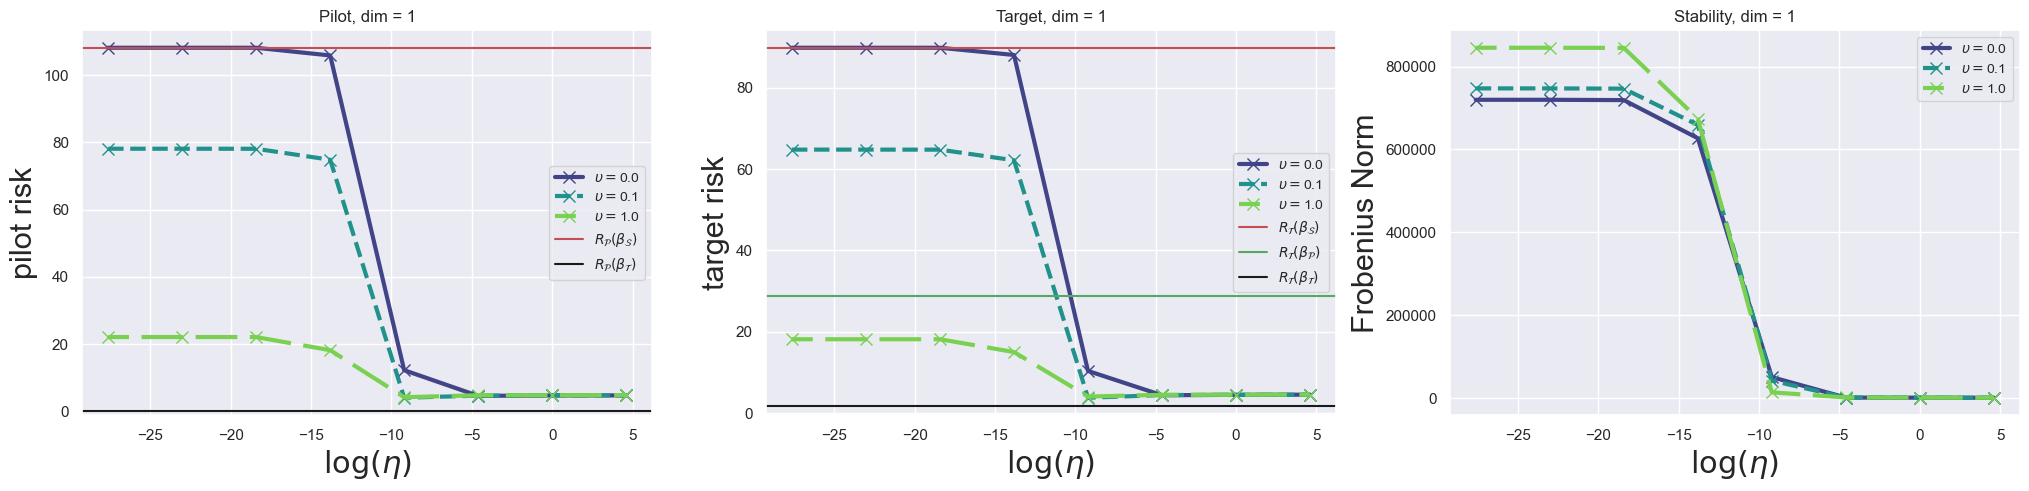

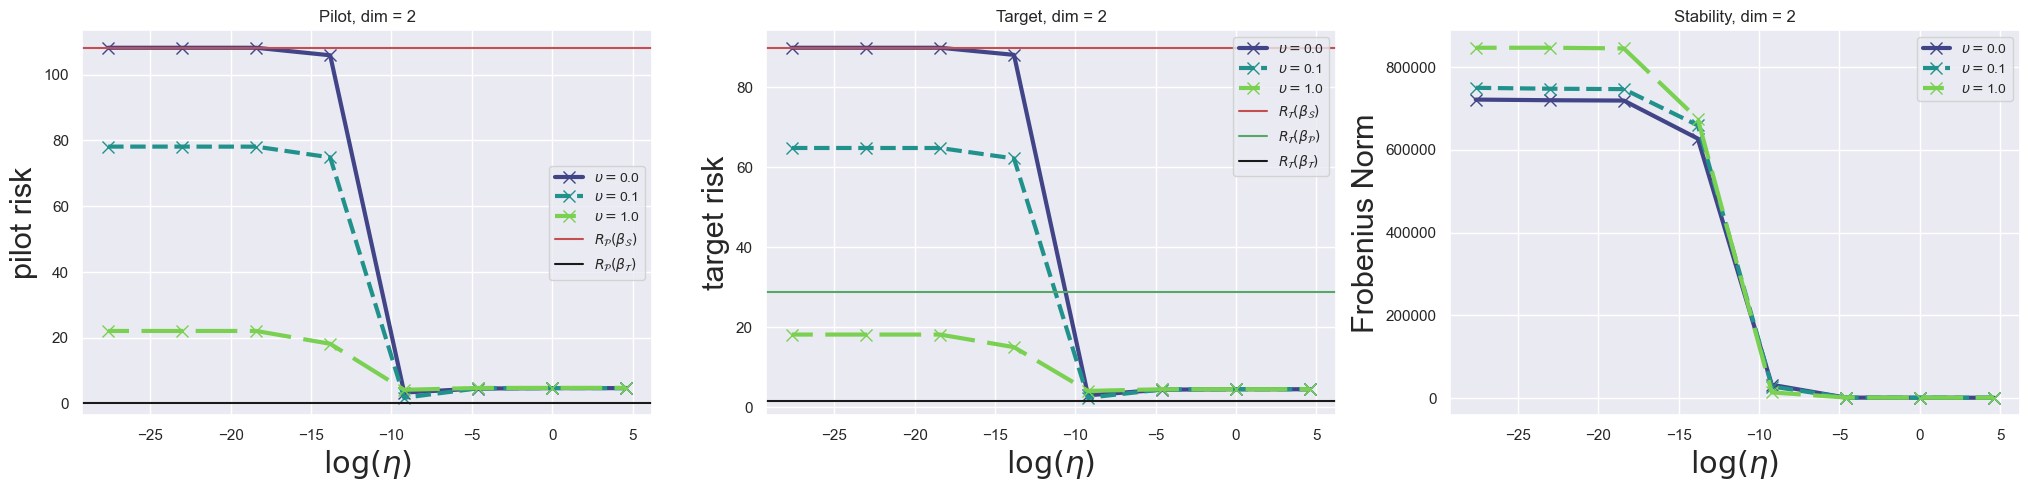

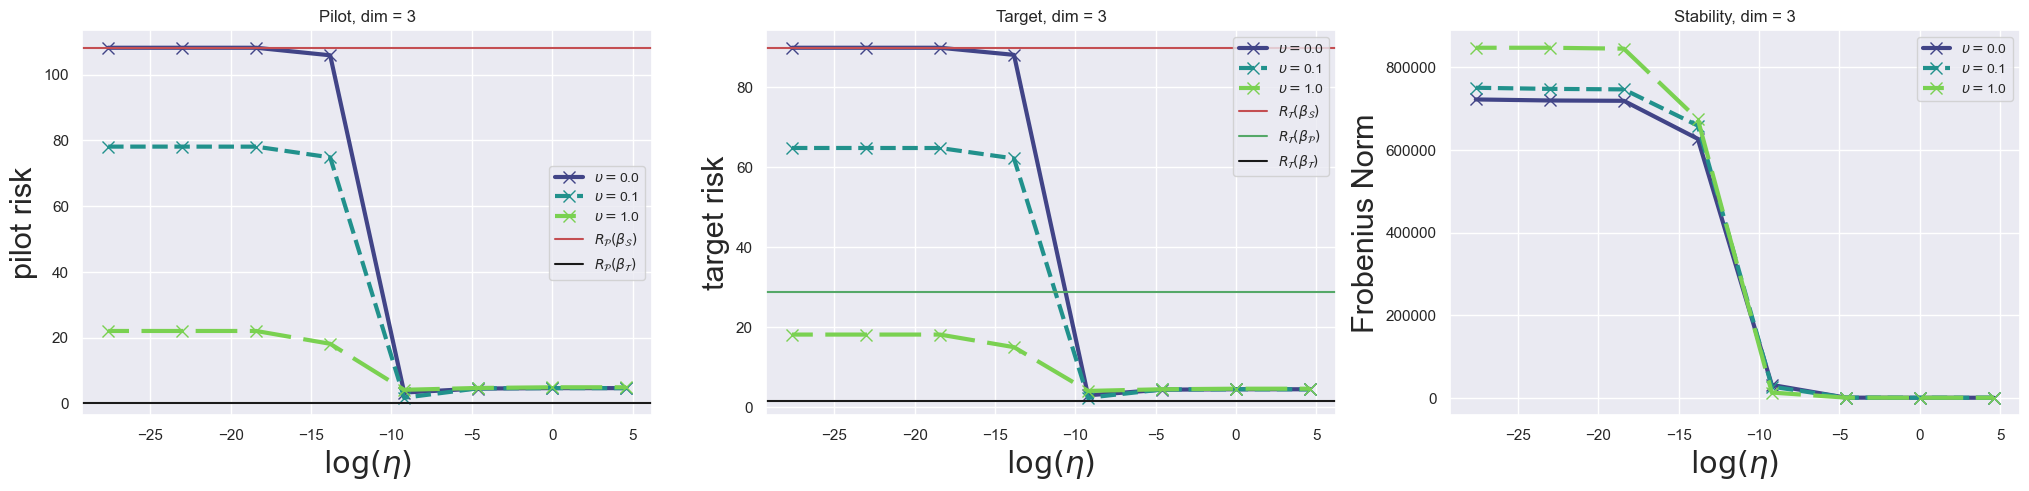

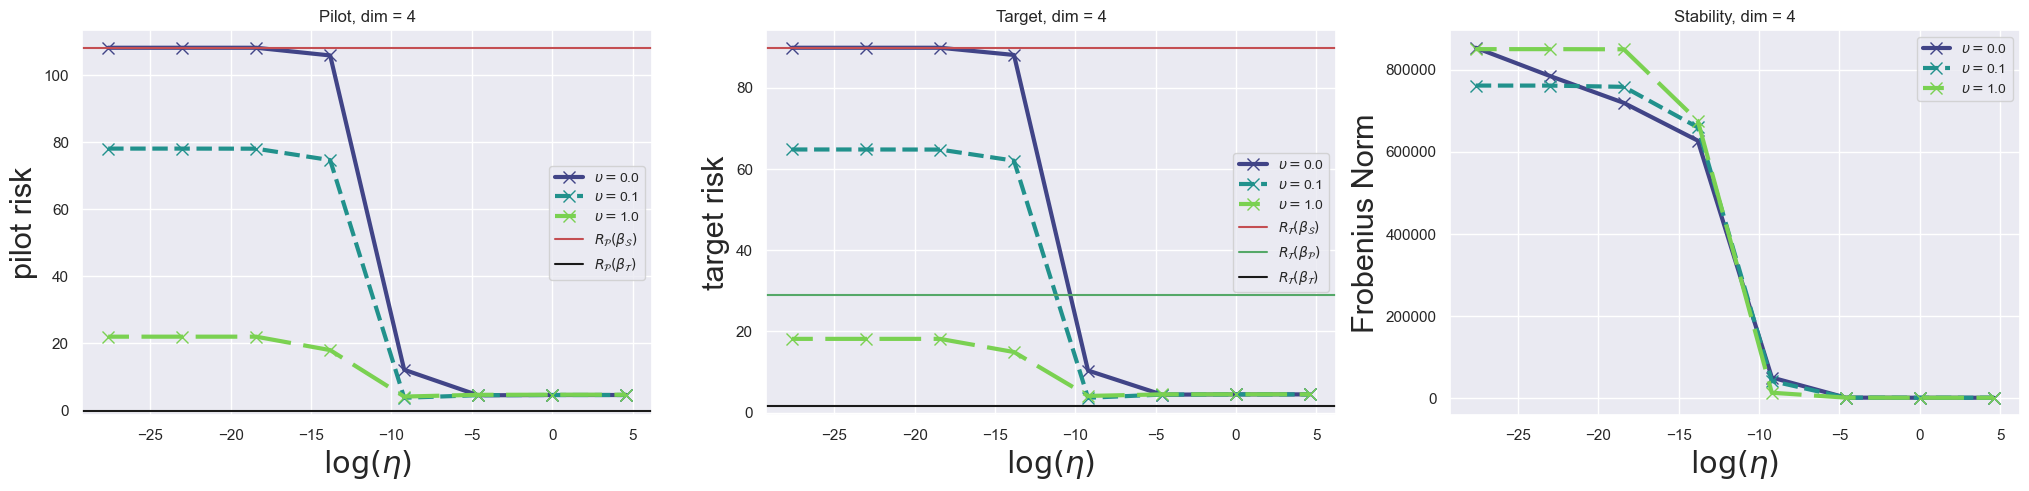

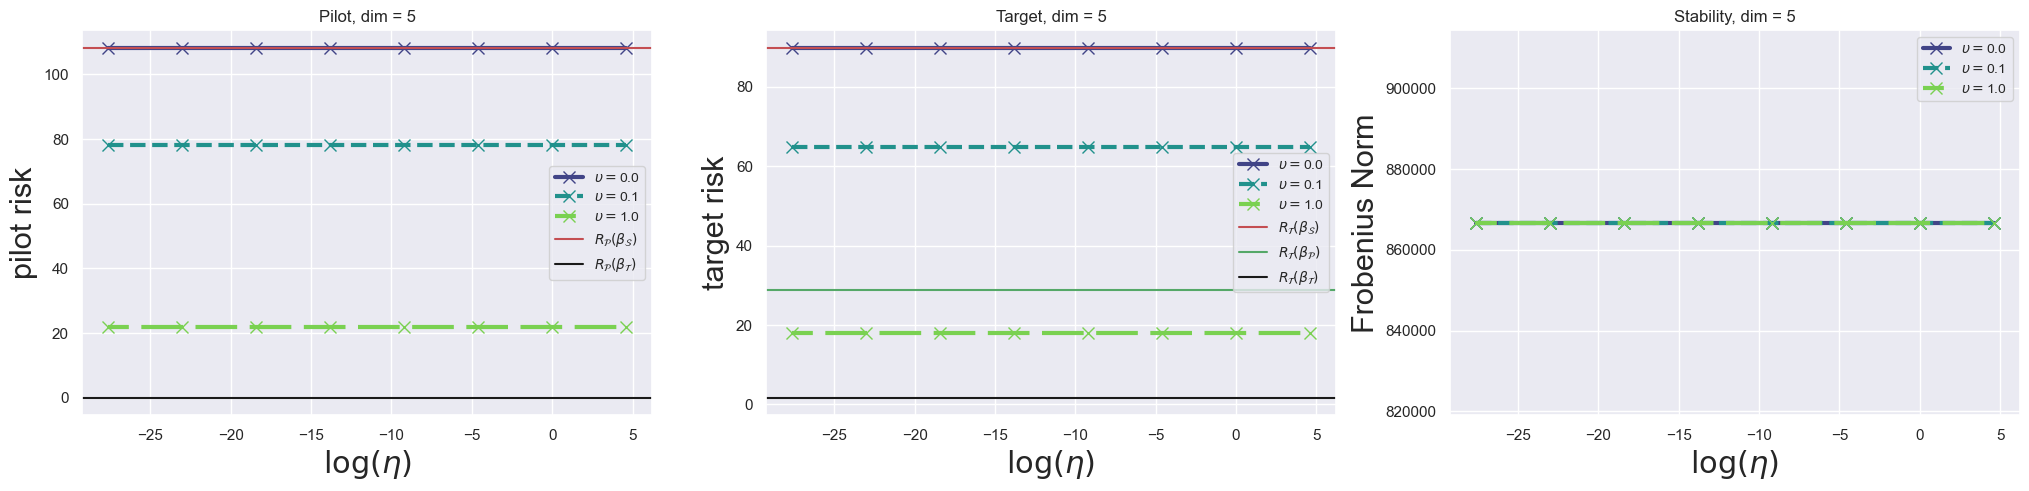

In [35]:
sns.set_theme()

linestyle_tuple = [
     ('loosely dotted',        (0, (1, 10))),
     ('dotted',                (0, (1, 1))),
     ('densely dotted',        (0, (1, 1))),
     ('long dash with offset', (5, (10, 3))),
     ('loosely dashed',        (0, (5, 10))),
     ('dashed',                (0, (5, 5))),
     ('densely dashed',        (0, (5, 1))),

     ('loosely dashdotted',    (0, (3, 10, 1, 10))),
     ('dashdotted',            (0, (3, 5, 1, 5))),
     ('densely dashdotted',    (0, (3, 1, 1, 1))),

     ('dashdotdotted',         (0, (3, 5, 1, 5, 1, 5))),
     ('loosely dashdotdotted', (0, (3, 10, 1, 10, 1, 10))),
     ('densely dashdotdotted', (0, (3, 1, 1, 1, 1, 1)))]


linestyle_list = ['solid', 'dashed', (5, (10, 3)), 'dotted', 'dashdot', 'dashdot', 'dashdot', 'dashdot', 'dashdot', 'dashdot', 'dashdot']
marker_list = ['s', 'o', 'D', 'X', 'P']
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(ups_range)))


for h, k in enumerate(dim_range):
    # pilot risk
    f, axs = plt.subplots(1, 3, figsize=(25, 5))

    for j in range(len(ups_range)):
        axs[0].plot(np.log(eta_range), pilot_risks_ridge[h, j,:, :], markersize=8, marker='x', color=colors[j], linestyle=linestyle_list[j], linewidth=3, label=r'$\upsilon=$'+str(ups_range[j]), alpha = 1)

    axs[0].axhline(R_pilot(beta_s), color='r', label=r'$R_\mathcal{P}(\beta_{\mathcal{S}})$')
    axs[0].axhline(R_pilot(beta_p), color='k', label=r'$R_\mathcal{P}(\beta_{\mathcal{T}})$')

    axs[0].set_ylabel('pilot risk', fontsize=22)
    axs[0].set_xlabel(r'$\log(\eta)$', fontsize=22)
    axs[0].legend(prop={'size': 10})
    axs[0].set_title("Pilot, dim = {}".format(k))
   

    # target risk
    for j in range(len(ups_range)):
        axs[1].plot(np.log(eta_range), target_risks_ridge[h, j,:, :], markersize=8, marker='x', color=colors[j], linestyle=linestyle_list[j], linewidth=3, label=r'$\upsilon=$'+str(ups_range[j]), alpha = 1)

    axs[1].axhline(R_t(beta_s), color='r', label=r'$R_\mathcal{T}(\beta_{\mathcal{S}})$')
    axs[1].axhline(R_t(beta_p), color='g', label=r'$R_\mathcal{T}(\beta_{\mathcal{P}})$')
    axs[1].axhline(R_t(beta_t), color='k', label=r'$R_\mathcal{T}(\beta_{\mathcal{T}})$')

    axs[1].set_ylabel('target risk', fontsize=22)
    axs[1].set_xlabel(r'$\log(\eta)$', fontsize=22)
    axs[1].legend(prop={'size': 10})
    axs[1].set_title("Target, dim = {}".format(k))
    
    for j in range(len(ups_range)):
        proj = torch.DoubleTensor(V_list[h, j, :, :,:],)
        disc = torch.linalg.norm(proj @ (XX_t_ - XX_s_)[None,:,:], "fro", dim = (2, 3))**2
        
        axs[2].plot(np.log(eta_range), disc, markersize=8, marker='x', color=colors[j], linestyle=linestyle_list[j], linewidth=3, label=r'$\upsilon=$'+str(ups_range[j]), alpha = 1)


    axs[2].set_ylabel('Frobenius Norm', fontsize=22)
    axs[2].set_xlabel(r'$\log(\eta)$', fontsize=22)
    axs[2].legend(prop={'size': 10})
    axs[2].set_title("Stability, dim = {}".format(k))

**Plots**

Reproduce the plots in Figure 2 of the paper.

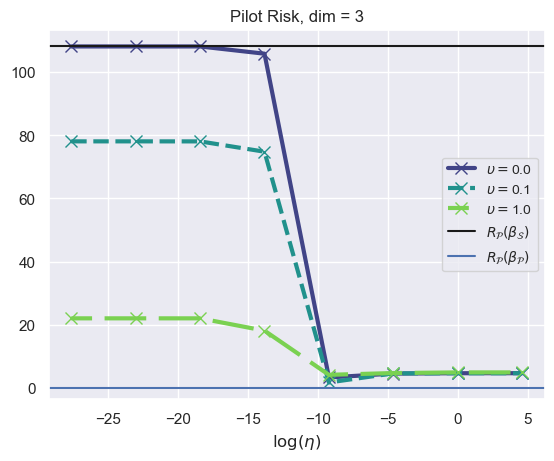

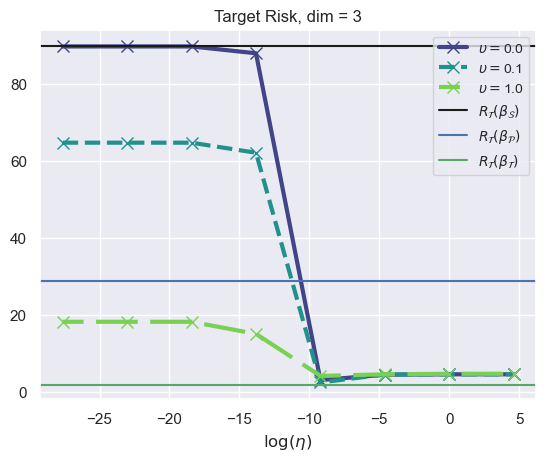

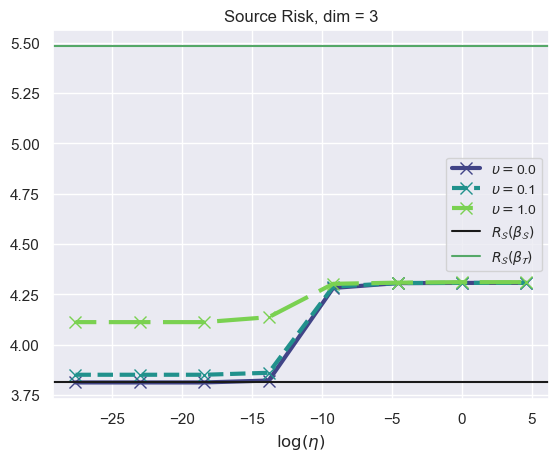

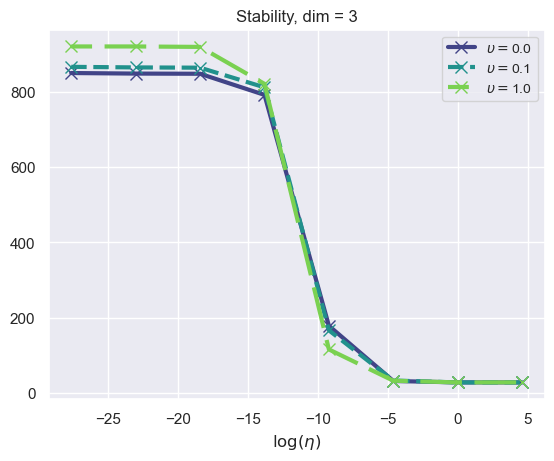

In [34]:
#Plots for dimenion k = 3
k = 3
#pilot, target, source, stability
for j in range(len(ups_range)):
    plt.plot(np.log(eta_range), pilot_risks_ridge[2, j,:, :], markersize=8, marker='x', color=colors[j], linestyle=linestyle_list[j], linewidth=3, label=r'$\upsilon=$'+str(ups_range[j]), alpha = 1)

plt.axhline(R_pilot(beta_s), color='k', label=r'$R_\mathcal{P}(\beta_{\mathcal{S}})$')
plt.axhline(R_pilot(beta_p), color='b', label=r'$R_\mathcal{P}(\beta_{\mathcal{P}})$')

#plt.ylabel('pilot risk', fontsize=22)
plt.xlabel(r'$\log(\eta)$')
plt.legend(prop={'size': 10})
plt.title("Pilot Risk, dim = {}".format(k))
plt.savefig("figs/InstitutionsPilotRisk.pdf")
plt.show()


for j in range(len(ups_range)):
    plt.plot(np.log(eta_range), target_risks_ridge[2, j,:, :], markersize=8, marker='x', color=colors[j], linestyle=linestyle_list[j], linewidth=3, label=r'$\upsilon=$'+str(ups_range[j]), alpha = 1)

plt.axhline(R_t(beta_s), color='k', label=r'$R_\mathcal{T}(\beta_{\mathcal{S}})$')
plt.axhline(R_t(beta_p), color='b', label=r'$R_\mathcal{T}(\beta_{\mathcal{P}})$')
plt.axhline(R_t(beta_t), color='g', label=r'$R_\mathcal{T}(\beta_{\mathcal{T}})$')

#plt.ylabel('target risk', fontsize=22)
plt.xlabel(r'$\log(\eta)$')
plt.legend(prop={'size': 10})
plt.title("Target Risk, dim = {}".format(k))
plt.savefig("figs/InstitutionsTargetRisk.pdf")
plt.show()


for j in range(len(ups_range)):
    plt.plot(np.log(eta_range), source_risks_ridge[2, j,:, :], markersize=8, marker='x', color=colors[j], linestyle=linestyle_list[j], linewidth=3, label=r'$\upsilon=$'+str(ups_range[j]), alpha = 1)

plt.axhline(R_s(beta_s), color='k', label=r'$R_\mathcal{S}(\beta_{\mathcal{S}})$')
plt.axhline(R_s(beta_t), color='g', label=r'$R_\mathcal{S}(\beta_{\mathcal{T}})$')

#plt.ylabel('source risk', fontsize=22)
plt.xlabel(r'$\log(\eta)$')
plt.legend(prop={'size': 10})
plt.title("Source Risk, dim = {}".format(k))
plt.savefig("figs/InstitutionsSourceRisk.pdf")
plt.show()


for j in range(len(ups_range)):
        proj = torch.DoubleTensor(V_list[2, j, :, :,:],)
        disc = torch.linalg.norm(proj @ (XX_t_ - XX_s_)[None,:,:], "fro", dim = (2, 3))
        
        plt.plot(np.log(eta_range), disc, markersize=8, marker='x', color=colors[j], linestyle=linestyle_list[j], linewidth=3, label=r'$\upsilon=$'+str(ups_range[j]), alpha = 1)


#plt.set_ylabel('Frobenius Norm', fontsize=22)
plt.xlabel(r'$\log(\eta)$')
plt.legend(prop={'size': 10})
plt.title("Stability, dim = {}".format(k))
plt.savefig("figs/InstitutionsStability.pdf")
plt.show()

**Plots**

Reproduce the plots in Figure 3 of the paper.

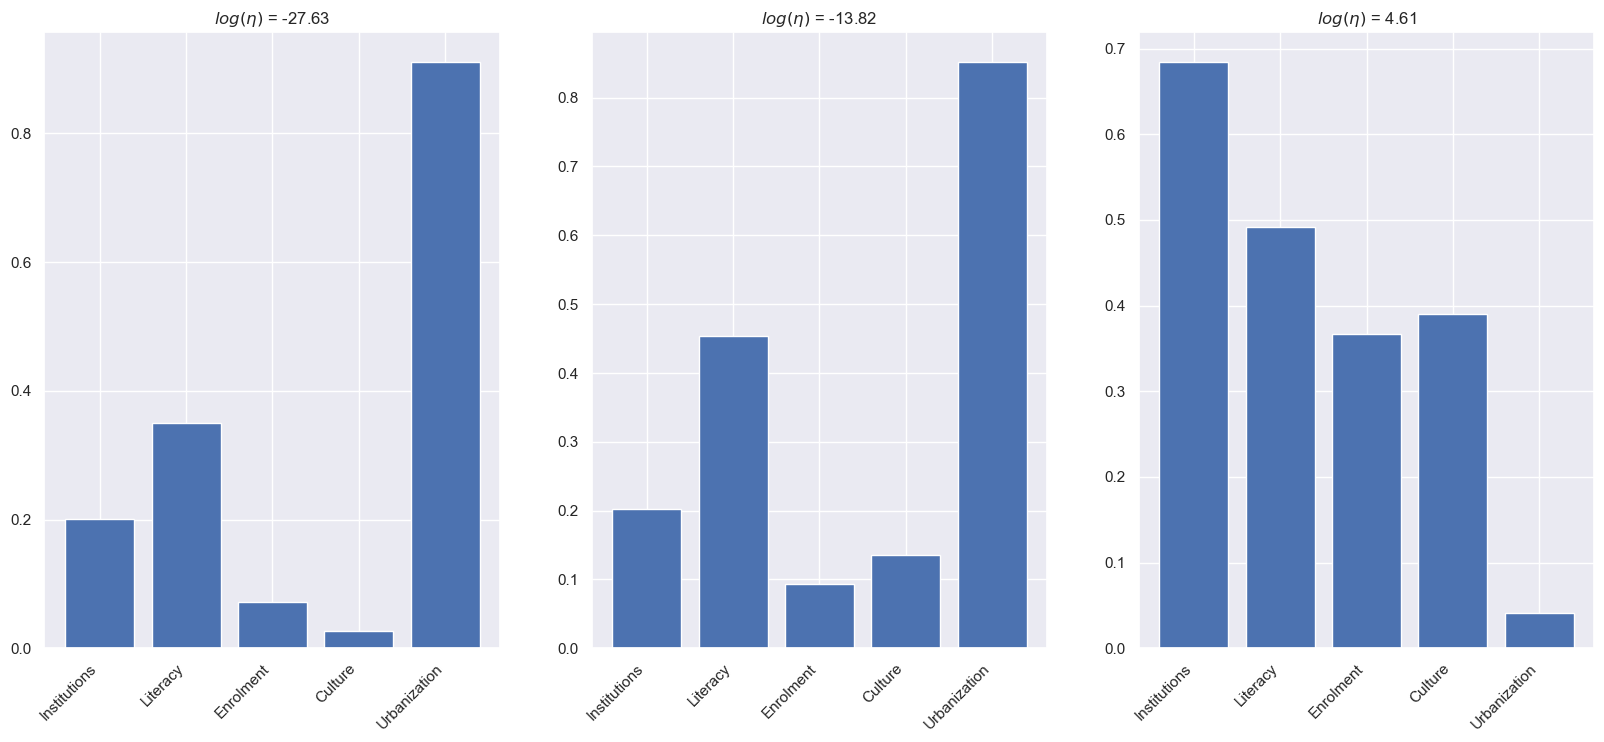

In [ ]:
colnames = xcols
xcolnames = ['Institutions', 'Literacy', 'Enrolment', 'Culture', "Urbanization"]
i=0
for h, k in enumerate(dim_range[:1]):
    #side by side bar plots
    f, axs = plt.subplots(1, 3, figsize=(20, 8))
    for j, eta in enumerate(eta_range):
        #if j%3==0:
        if j == 0 or j == 3 or j == 7:
            proj = V_list[h, 0, j, 0,:,:]
            S, U= np.linalg.eigh(proj)
            axs[i].bar(df_X.columns[:], np.abs(U[:,-1]))
            axs[i].set_xticks(df_X.columns[:], xcolnames, rotation=45, ha='right')
            axs[i].set_title(r"$log(\eta)$ = {}".format(np.round(np.log(eta), 2)))
            i+=1
        
f.savefig("figs/InstitutionsSubspaceBarplot.pdf")